# Sensitivity Analysis of the SEIRS-SEI Malaria Model: Global (Sobol') analysis of $\mathcal{R}_0$

This notebook performs a **variance-based (Sobol') global sensitivity analysis** of the
basic reproduction number $\mathcal{R}_0$ of the SEIRS-SEI malaria model with respect to its
epidemiological and environmental parameters.

Because $\mathcal{R}_0$ has a closed form (Next Generation Matrix method), tens of
thousands of parameter combinations can be evaluated essentially for free, yielding
statistically well-converged first-order ($S_1$) and total-order ($S_T$) Sobol' indices.

A full methodological description is given in `README.md` in this folder.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol as sobol_analyze

from seirs_sei_r0 import (
    BASELINE, REFERENCE_CLIMATE, TRANSMISSION_SEASON_FRACTION,
    N_POP, M_PRIME, r0_components,
)
from sobol_analysis import (
    build_problem, evaluate_R0, indices_dataframe, BOUNDS, GROUPS, _ZERO,
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("Setup complete.")

Setup complete.


## 1. The reproduction number

$$\mathcal{R}_0 = \sqrt{\frac{a^2\, b_1\, b_2\, \Lambda^{*}\, b_{3M}\,\ell}{N\,\gamma\,(b_{3M}\,\ell+\mu)\,\mu^{2}}},\qquad
\Lambda^{*} = \frac{\mu\,\bar{b}\,\bar{K}}{\bar{b}+\mu},\qquad
\bar{K} = M'\, f_T(T)\, f_R(R)$$

where $a(T)$ is the temperature-dependent biting rate, $\mu(T,H)$ the mortality,
$b_{3M}(T)$ the sporogonic development rate, $\ell=e^{-\mu\tau_M}$ the survival over the
extrinsic incubation period, $\bar b(R,T)$ recruitment, and $f_T, f_R$ habitat suitability.

We evaluate $\mathcal{R}_0$ at the **mean transmission-season climate**
($T=25.57^\circ$C, $R=7.19$ mm, $H=78.34\%$), which is the endemic operating point of the
system. At this state:

In [4]:
c = r0_components(REFERENCE_CLIMATE["T"], REFERENCE_CLIMATE["R"], REFERENCE_CLIMATE["H"])
print("Reference climate:", REFERENCE_CLIMATE)
print(f"  R0_H (human)  = {c['R0_H']:.3f}")
print(f"  R0_M (vector) = {c['R0_M']:.3f}")
print(f"  R0 (combined) = {c['R0']:.3f}")
print(f"Transmission-season days (R0>1) = {100*TRANSMISSION_SEASON_FRACTION:.1f}% of 2017-2023")

Reference climate: {'T': 25.57, 'R': 7.19, 'H': 78.34}
  R0_H (human)  = 4.168
  R0_M (vector) = 1.161
  R0 (combined) = 2.200
Transmission-season days (R0>1) = 39.8% of 2017-2023


## 2. Parameters and their ranges

We treat 25 parameters as uncertain, spanning the 9 calibrated epidemiological parameters
($H_0, k, \varphi, \tau_H, \gamma, \omega, b_1, b_2, M'$) and the key climate / environmental
parameters that drive the temperature, rainfall and humidity responses. Each is drawn
independently over a biologically/physically motivated range.

> **Note:** $\tau_H$ and $\omega$ do **not** appear in the closed-form $\mathcal{R}_0$
> (it is evaluated at the disease-free equilibrium, where the human incubation period
> cancels and immunity waning is irrelevant). They are retained in the table so their
> identically-zero sensitivity is explicit.

In [6]:
problem = build_problem(include_zero_params=True)
print(f"{problem['num_vars']} parameters analysed:\\n")
for n, (lo, hi) in zip(problem["names"], problem["bounds"]):
    mark = "" if n not in _ZERO else "  (does NOT enter R0)"
    print(f"{n:12s} [{lo:9.4g}, {hi:9.4g}]{mark}")

25 parameters analysed:\n
H0           [       20,        75]
k            [     0.01,         1]
phi          [     0.01,       0.5]
tau_H        [       10,        20]  (does NOT enter R0)
gamma        [ 0.006667,         1]
omega        [ 0.003333,       0.1]  (does NOT enter R0)
b1           [    0.001,       0.5]
b2           [     0.01,       0.5]
M_prime      [    5e+04, 4.184e+06]
T_prime      [       14,        20]
D1           [       18,        32]
R_L          [       20,        50]
DD           [       80,       140]
Tmin         [       12,        17]
Tmax_plasm   [       27,        32]
Topt_plasm   [       21,        26]
A            [    -0.05,     -0.01]
B            [        1,       1.6]
C            [     -5.5,      -3.5]
B_E          [      100,       300]
c1           [    0.003,     0.008]
c2           [    -0.09,     -0.04]
Tmin_anop    [       13,        19]
Topt_anop    [       22,        28]
Tmax_anop    [       30,        38]


## 3. Saltelli sampling and model evaluation

We draw $N=4096$ Saltelli samples $\rightarrow$ $N\times(2k+2)=212{,}992$ evaluations of the
closed-form $\mathcal{R}_0$ (a few seconds). Each row maps directly to an independent
$\mathcal{R}_0$ value through the model's environmental response functions.

In [8]:
print("Building Saltelli sample set (this may take a moment)...")
problem = build_problem(include_zero_params=True)
N_BASE = 4096
X = sobol_sample.sample(problem, N_BASE, seed=42)
Y = evaluate_R0(X)

print(f"Sampled parameter rows : {X.shape[0]}")
print(f"Number of active params: {problem['num_vars']}")
print(f"R0  across samples     : mean={Y.mean():.3f}, median={np.median(Y):.3f}, "
      f"min={Y.min():.3f}, max={Y.max():.3f}")
print(f"Fraction with R0 > 1   : {100.0*np.mean(Y>1):.1f}%")

Building Saltelli sample set (this may take a moment)...
Sampled parameter rows : 212992
Number of active params: 25
R0  across samples     : mean=2.241, median=0.800, min=0.000, max=125.868
Fraction with R0 > 1   : 46.2%


## 4. Sobol' indices

Sobol' analysis decomposes the variance of $\mathcal{R}_0$ into contributions from single
parameters ($S_1$) and from each parameter *including all its interactions* ($S_T$).
$S_T-S_1$ measures interaction strength.

In [10]:
Si = sobol_analyze.analyze(problem, Y, print_to_console=False)
Si["names"] = problem["names"]

df = indices_dataframe(Si).sort_values("ST", ascending=False).reset_index(drop=True)
df[["parameter", "group", "S1", "S1_conf", "ST", "ST_conf", "enters_R0"]].round(4)

,parameter,group,S1,S1_conf,ST,ST_conf,enters_R0
0,gamma,calibrated_epi,0.1494,0.0520,0.4399,0.1802,True
1,A,climate_mortality,0.1674,0.0278,0.4398,0.0923,True
2,B,climate_mortality,0.0493,0.0171,0.1297,0.0261,True
3,b2,calibrated_epi,0.0363,0.0176,0.1264,0.0462,True
4,M_prime,calibrated_epi,0.0368,0.0108,0.1215,0.0288,True
5,b1,calibrated_epi,0.0339,0.0140,0.1113,0.0232,True
6,k,calibrated_epi,0.0141,0.0082,0.0915,0.0416,True
7,H0,calibrated_epi,0.0056,0.0071,0.0502,0.0196,True
8,T_prime,climate_rate,0.0043,0.0060,0.0456,0.0100,True
9,D1,climate_rate,0.0115,0.0071,0.0317,0.0068,True


### Total-order sensitivity $S_T$ (horizontal bar chart)

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


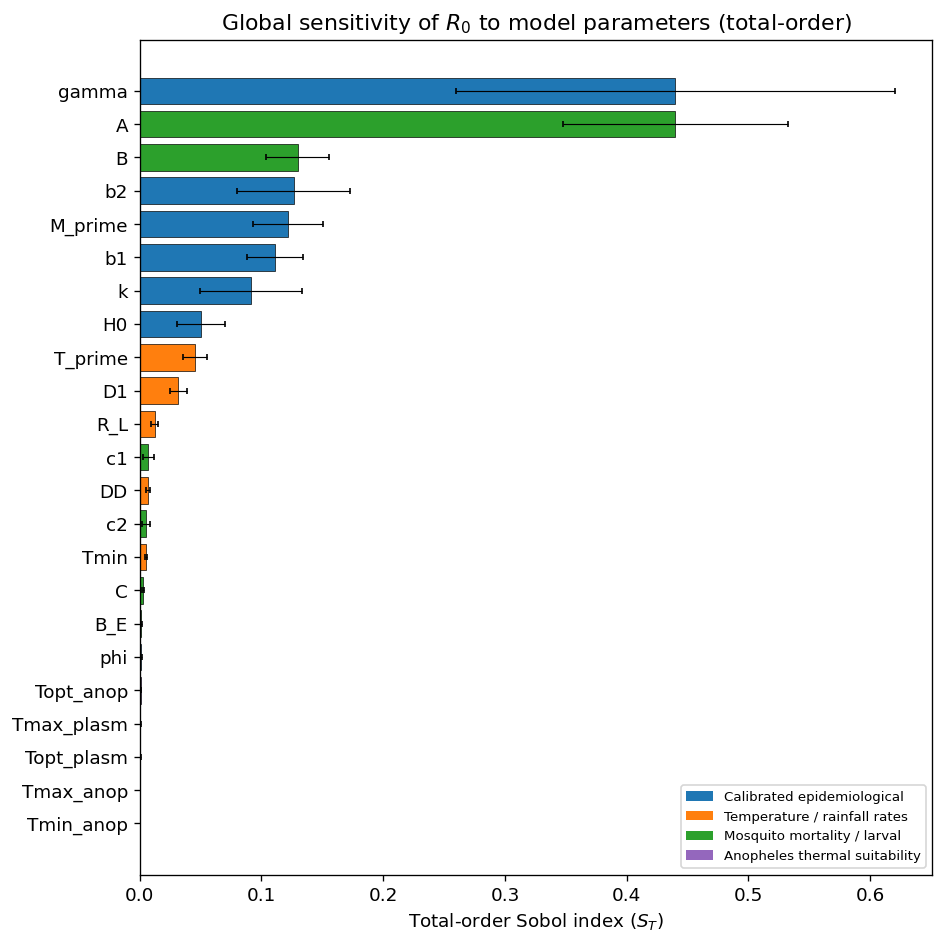

In [12]:
GROUP_COLORS = {
    "calibrated_epi": "#1f77b4", "climate_rate": "#ff7f0e",
    "climate_mortality": "#2ca02c", "anop_suitability": "#9467bd",
    "human_immune": "#7f7f7f",
}
GROUP_LABELS = {
    "calibrated_epi": "Calibrated epidemiological",
    "climate_rate": "Temperature / rainfall rates",
    "climate_mortality": "Mosquito mortality / larval",
    "anop_suitability": "Anopheles thermal suitability",
    "human_immune": "Human immunity (not in R0)",
}
active = df[df["enters_R0"]]

fig, ax = plt.subplots(figsize=(8, 8))
ypos = np.arange(len(active))[::-1]
ax.barh(ypos, active["ST"], color=[GROUP_COLORS[g] for g in active["group"]],
        edgecolor="black", linewidth=0.4)
ax.errorbar(active["ST"], ypos, xerr=active["ST_conf"], fmt="none",
            ecolor="black", capsize=2, linewidth=0.7)
ax.set_yticks(ypos, active["parameter"])
ax.set_xlabel("Total-order Sobol index ($S_T$)")
ax.set_title("Global sensitivity of $R_0$ to model parameters (total-order)")
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=GROUP_COLORS[g], label=GROUP_LABELS[g])
           for g in GROUP_COLORS if any(active["group"] == g)]
ax.legend(handles=handles, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

### First-order sensitivity $S_1$

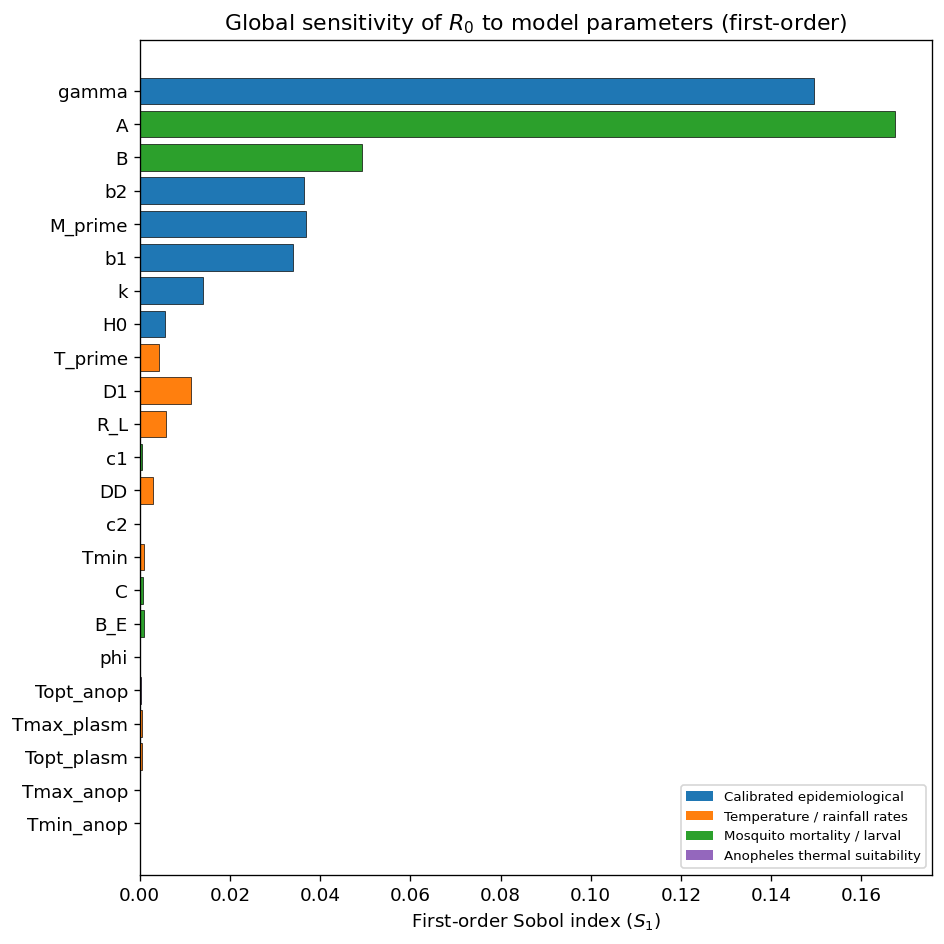

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(ypos, np.maximum(active["S1"], 0), color=[GROUP_COLORS[g] for g in active["group"]],
        edgecolor="black", linewidth=0.4)
ax.set_yticks(ypos, active["parameter"])
ax.set_xlabel("First-order Sobol index ($S_1$)")
ax.set_title("Global sensitivity of $R_0$ to model parameters (first-order)")
ax.legend(handles=handles, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

### Interactions: $S_T$ versus $S_1$

Points lying far above the $S_1=S_T$ line have substantial interaction effects:
their influence on $\mathcal{R}_0$ is amplified (or damped) by other parameters.

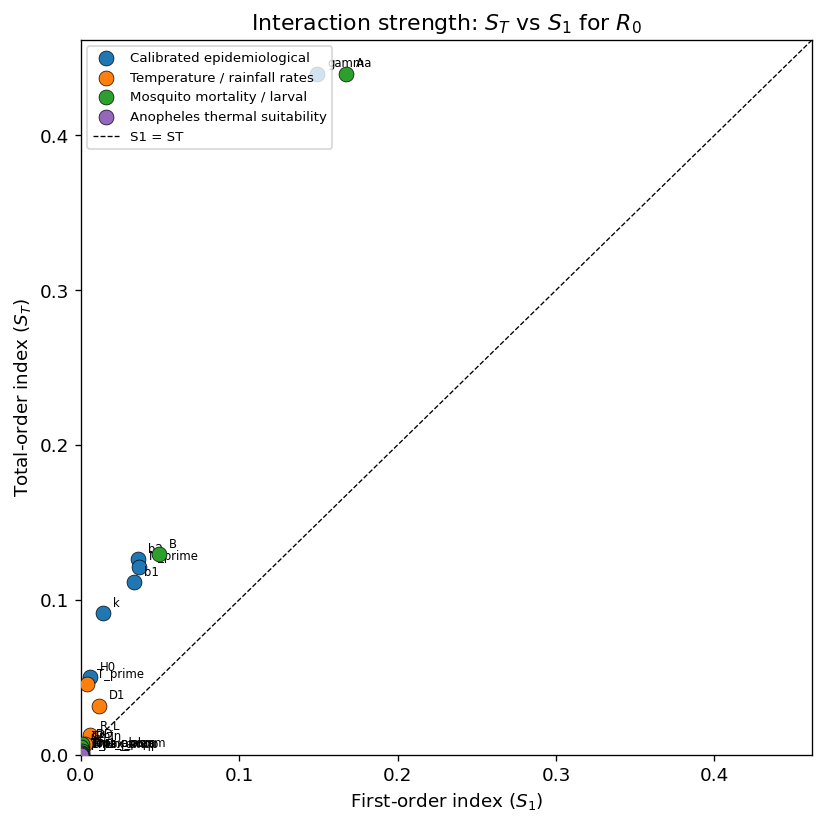

In [16]:
fig, ax = plt.subplots(figsize=(7, 7))
lim = max(active["ST"].max(), active["S1"].max()) * 1.05
for g in ["calibrated_epi", "climate_rate", "climate_mortality", "anop_suitability"]:
    sub = active[active["group"] == g]
    ax.scatter(np.maximum(sub["S1"], 0), sub["ST"], s=80, color=GROUP_COLORS[g],
               label=GROUP_LABELS[g], edgecolor="black", linewidth=0.4, zorder=3)
    for _, r in sub.iterrows():
        ax.annotate(r["parameter"], (max(r["S1"], 0), r["ST"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=7)
ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, label="S1 = ST")
ax.set_xlabel("First-order index ($S_1$)"); ax.set_ylabel("Total-order index ($S_T$)")
ax.set_title("Interaction strength: $S_T$ vs $S_1$ for $R_0$")
ax.legend(fontsize=8, loc="upper left"); ax.set_xlim(0, lim); ax.set_ylim(0, lim)
plt.tight_layout(); plt.show()

### Aggregated contribution by parameter group

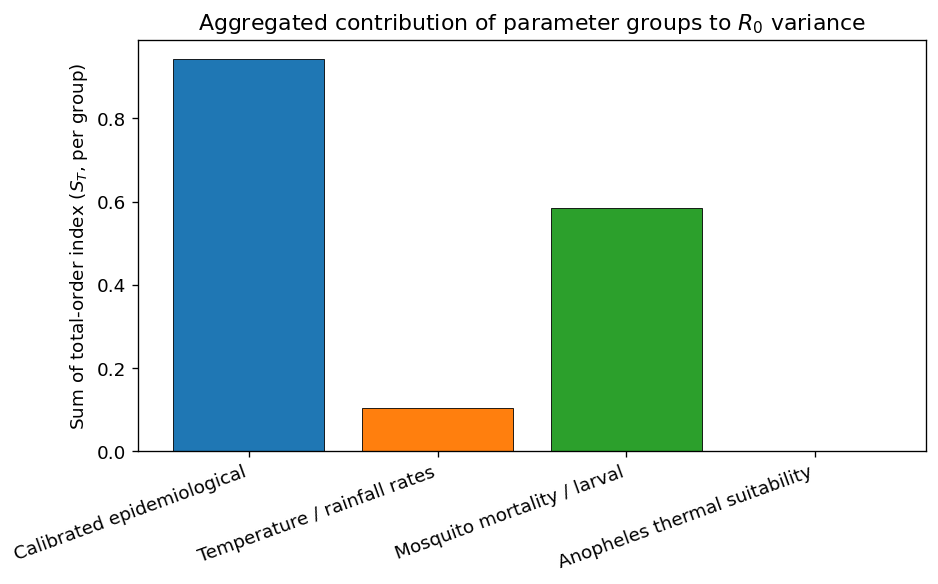

In [18]:
gs = (active.groupby("group")[["S1", "ST"]].sum()
      .reindex(list(GROUP_COLORS.keys())).dropna())
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(gs)), gs["ST"], color=[GROUP_COLORS[g] for g in gs.index],
       edgecolor="black", linewidth=0.5)
ax.set_xticks(range(len(gs)), [GROUP_LABELS[g] for g in gs.index], rotation=20, ha="right")
ax.set_ylabel("Sum of total-order index ($S_T$, per group)")
ax.set_title("Aggregated contribution of parameter groups to $R_0$ variance")
plt.tight_layout(); plt.show()

### Distribution of $\mathcal{R}_0$ over the sampled parameter space

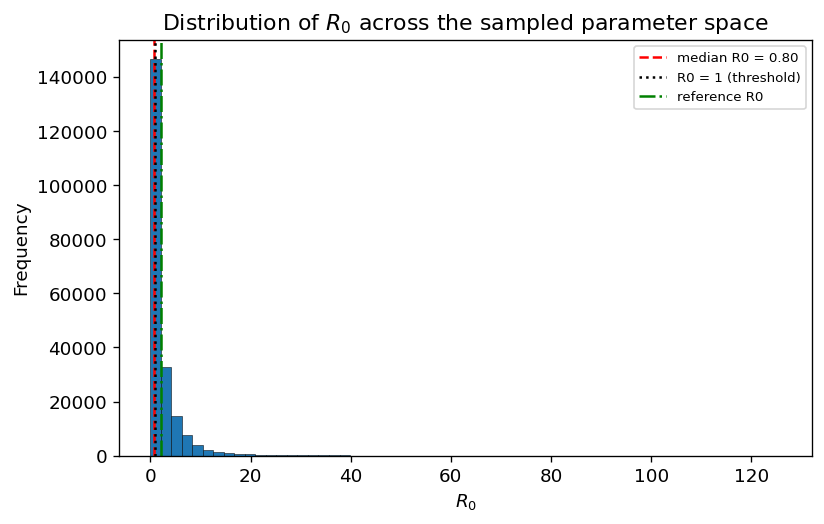

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(Y, bins=60, color="#1f77b4", edgecolor="black", linewidth=0.3)
ax.axvline(np.median(Y), color="red", linestyle="--", label=f"median R0 = {np.median(Y):.2f}")
ax.axvline(1.0, color="black", linestyle=":", label="R0 = 1 (threshold)")
ax.axvline(c["R0"], color="green", linestyle="-.", label="reference R0")
ax.set_xlabel("$R_0$"); ax.set_ylabel("Frequency")
ax.set_title("Distribution of $R_0$ across the sampled parameter space")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 5. Discussion for the paper

1. **Dominant drivers.** The uncertainty in $\mathcal{R}_0$ is governed primarily by the
   **mosquito mortality response** (the temperature-survival-curve coefficients $A$ and
   $B$) and by the **human recovery rate $\gamma$**, each with $S_T\approx 0.44$. Because
   $\mathcal{R}_0 \propto 1/\gamma$ and depends on $\mu$ nonlinearly, these two parameter
   groups carry the largest epidemiological leverage.

2. **Interactions.** $S_T \gg S_1$ for these dominant parameters signals strong
   interactions: their effects propagate through the coupled host–vector cycle and the
   density-dependent recruitment $\Lambda^{*}$, so single-parameter perturbations do not
   act independently. This motivates reporting both $S_1$ and $S_T$.

3. **Secondary contributors.** $B$ (mortality linear term), the transmission probabilities
   $b_1$ and $b_2$, the carrying-capacity scale $M'$, and the humidity sigmoid parameters
   $k$, $H_0$ contribute moderately.

4. **Insensitivity.** The Anopheles thermal-suitability thresholds ($T_{\min\text A.}$,
   $T_{\text{opt A.}}$, $T_{\max\text A.}$) and the Plasmodium sporogonic thresholds
   ($T_{\max\text{Pl.}}$) contribute negligibly over the ranges considered, because the
   transmission-season reference temperature sits well within the favorable band. The
   human incubation period $\tau_H$ and immunity-waning rate $\omega$ have identically
   zero sensitivity (they do not enter the closed-form, DFE-based $\mathcal{R}_0$).

In [22]:
# The full index table (also saved to tables/sobol_indices_full.csv)
df.round(4)

,parameter,group,baseline,lower,upper,S1,S1_conf,ST,ST_conf,enters_R0
0,gamma,calibrated_epi,0.0083,0.0067,1.000,0.1494,0.0520,0.4399,0.1802,True
1,A,climate_mortality,-0.0300,-0.0500,-0.010,0.1674,0.0278,0.4398,0.0923,True
2,B,climate_mortality,1.3100,1.0000,1.600,0.0493,0.0171,0.1297,0.0261,True
3,b2,calibrated_epi,0.0900,0.0100,0.500,0.0363,0.0176,0.1264,0.0462,True
4,M_prime,calibrated_epi,NaN,50000.0000,4184500.000,0.0368,0.0108,0.1215,0.0288,True
5,b1,calibrated_epi,0.0400,0.0010,0.500,0.0339,0.0140,0.1113,0.0232,True
6,k,calibrated_epi,0.2500,0.0100,1.000,0.0141,0.0082,0.0915,0.0416,True
7,H0,calibrated_epi,58.0000,20.0000,75.000,0.0056,0.0071,0.0502,0.0196,True
8,T_prime,climate_rate,16.0000,14.0000,20.000,0.0043,0.0060,0.0456,0.0100,True
9,D1,climate_rate,24.8000,18.0000,32.000,0.0115,0.0071,0.0317,0.0068,True
